**Import Libraries**

In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# These libraries are used for machine learning model training and evaluation.

**Load Processed Dataset**

In [13]:
df = pd.read_csv("train_processed.csv")

df.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,False,True,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,False,True,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,False,True,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,False,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,False,True,False,False,False,True,False


**Separate Features and Target**

In [14]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

**Explanation:**

X → input features

y → target variable (house price)

**Train-Test Split**

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Explanation:**

80% → training data

20% → testing data

This helps evaluate the model on unseen data.

**Train Linear Regression Model**

In [16]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

**Evaluate Linear Regression**

In [18]:
print("R2 Score:", r2_score(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))

R2 Score: 0.6554926552252471
RMSE: 51405.09425333483
MAE: 20232.175887935042


**Metrics meaning:**

R² Score → model accuracy

RMSE → prediction error

MAE → average absolute error

**Train Random Forest Model**

Random Forest usually performs better for house price prediction.

In [19]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

**Evaluate Random Forest**

In [21]:
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))

R2 Score: 0.8952010298882774
RMSE: 28352.112565630196
MAE: 17481.776643835616


**Feature Importance**

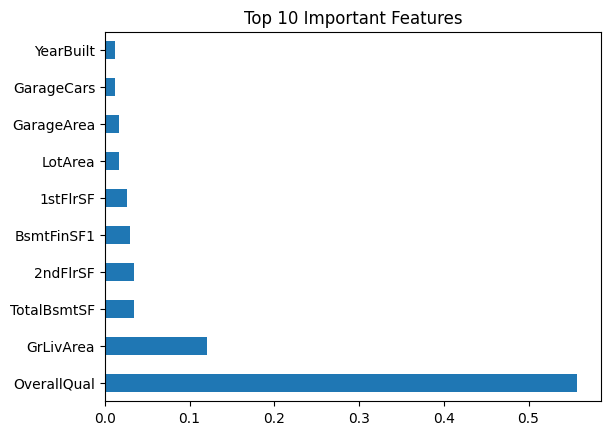

In [22]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

feat_importance = pd.Series(importances, index=features)

feat_importance.nlargest(10).plot(kind="barh")

plt.title("Top 10 Important Features")
plt.show()

This shows which features influence price the most.

**Save the Model**

In [23]:
import joblib

joblib.dump(rf, "house_price_model.pkl")

['house_price_model.pkl']

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import joblib

# Load original dataset
df = pd.read_csv(r"C:\Users\moodu\OneDrive\Documents\House_Price_Prediction\train.csv")

# Select ONLY the 5 features used in the app
features = ["OverallQual", "GrLivArea", "GarageCars", "GarageArea", "TotalBsmtSF"]
target = "SalePrice"

# Drop rows with missing values in these columns
df = df[features + [target]].dropna()

X = df[features]
y = df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Save model
joblib.dump(rf, r"C:\Users\moodu\OneDrive\Documents\House_Price_Prediction\house_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!
